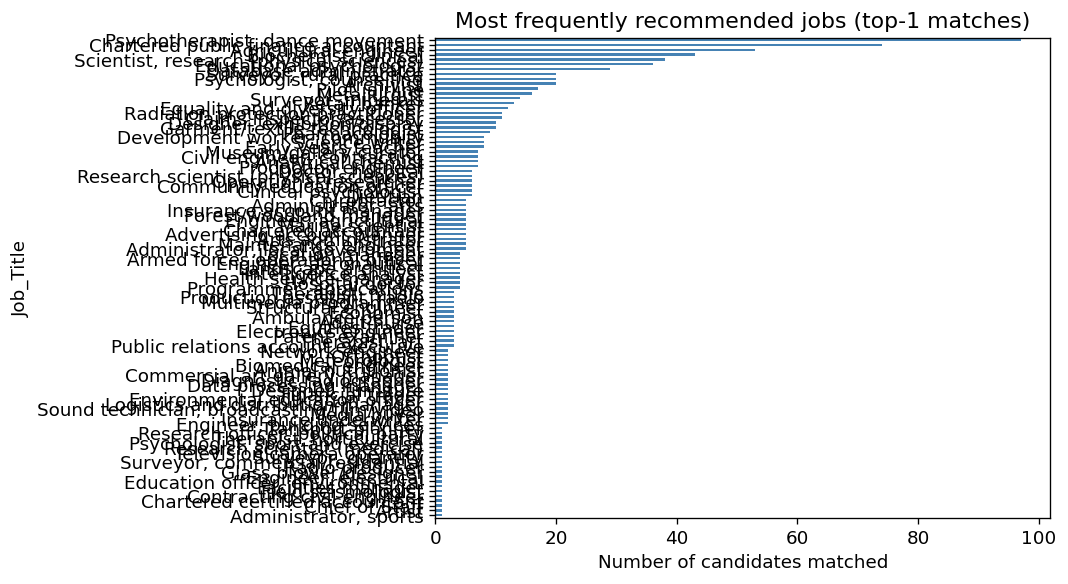

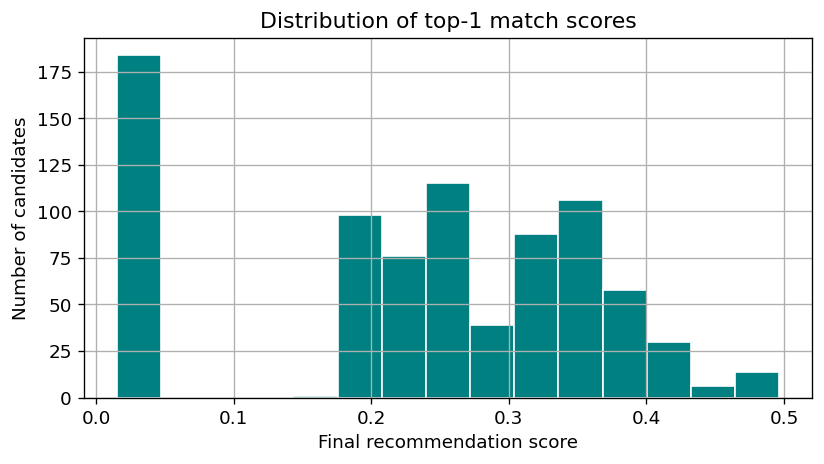

All charts saved to outputs/


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.patches import Rectangle

recs_df = pd.read_csv('../outputs/recommendations_with_metrics.csv')
jobs    = pd.read_csv('../data/processed/jobs_clean.csv')

# ══════════════════════════════════════════════════════════════════
# PROFESSIONAL STYLING - RED & BLACK THEME
# ══════════════════════════════════════════════════════════════════
# Color palette
PRIMARY_RED = '#dc143c'      # Crimson Red
PRIMARY_BLACK = '#1a1a1a'   # Deep Black
LIGHT_RED = '#fff5f5'       # Light red background
ACCENT_GRAY = '#2d2d2d'     # Dark gray

# Set professional style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelcolor'] = PRIMARY_BLACK
plt.rcParams['text.color'] = PRIMARY_BLACK
plt.rcParams['axes.edgecolor'] = ACCENT_GRAY
plt.rcParams['grid.color'] = '#e0e0e0'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

print("=" * 70)
print("JOB RECOMMENDATION DASHBOARD - PROFESSIONAL ANALYSIS")
print("=" * 70)

# ──────────────────────────────────────────────────────────────────
# CHART 1 — Top recommended jobs (Horizontal bar chart - Professional)
# ──────────────────────────────────────────────────────────────────
top1_counts = (recs_df[recs_df['Rank'] == 1]
               .groupby('Job_Title')
               .size()
               .sort_values(ascending=True)
               .tail(12))  # Top 12

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top1_counts)), top1_counts.values, 
               color=PRIMARY_RED, alpha=0.85, edgecolor=PRIMARY_BLACK, linewidth=1.5)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top1_counts.values)):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{int(val)}', va='center', fontweight='bold', color=PRIMARY_BLACK)

ax.set_yticks(range(len(top1_counts)))
ax.set_yticklabels(top1_counts.index, fontsize=10)
ax.set_xlabel('Number of Candidates Matched', fontsize=12, fontweight='bold')
ax.set_title('Top 12 Most Frequently Recommended Jobs\n(Rank #1 Matches)', 
             fontsize=14, fontweight='bold', color=PRIMARY_BLACK, pad=20)
ax.set_facecolor(LIGHT_RED)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(ACCENT_GRAY)
ax.spines['bottom'].set_color(ACCENT_GRAY)
ax.grid(axis='x', alpha=0.4, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/chart_top_jobs.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Chart 1: Top recommended jobs - GENERATED")

# ──────────────────────────────────────────────────────────────────
# CHART 2 — Similarity score distribution (Professional histogram)
# ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

scores = recs_df[recs_df['Rank'] == 1]['Final_Score']
n, bins, patches = ax.hist(scores, bins=20, color=PRIMARY_RED, alpha=0.75, 
                            edgecolor=PRIMARY_BLACK, linewidth=1.5)

# Color gradient effect
for patch in patches:
    patch.set_facecolor(PRIMARY_RED)
    patch.set_edgecolor(PRIMARY_BLACK)

# Add statistics
mean_score = scores.mean()
median_score = scores.median()
ax.axvline(mean_score, color='#1a1a1a', linestyle='--', linewidth=2.5, label=f'Mean: {mean_score:.4f}')
ax.axvline(median_score, color='#ff6b6b', linestyle='-.', linewidth=2.5, label=f'Median: {median_score:.4f}')

ax.set_xlabel('Final Recommendation Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (Number of Candidates)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Top-1 Match Scores\nScoring Metrics & Statistics', 
             fontsize=14, fontweight='bold', color=PRIMARY_BLACK, pad=20)
ax.set_facecolor(LIGHT_RED)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(ACCENT_GRAY)
ax.spines['bottom'].set_color(ACCENT_GRAY)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.grid(axis='y', alpha=0.4, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/chart_score_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Chart 2: Score distribution - GENERATED")

# ──────────────────────────────────────────────────────────────────
# CHART 3 — Professional Interactive table (Plotly - Red & Black)
# ──────────────────────────────────────────────────────────────────
top1_df = recs_df[recs_df['Rank'] == 1][[
    'Candidate_Name', 'Candidate_Exp_Level',
    'Job_Title', 'Company', 'Location',
    'Salary', 'Final_Score'
]].rename(columns={
    'Candidate_Name':      'Candidate',
    'Candidate_Exp_Level': 'Experience Level',
    'Job_Title':           'Recommended Job',
    'Final_Score':         'Match Score'
}).reset_index(drop=True)

# Round score for display
top1_df['Match Score'] = top1_df['Match Score'].round(4)

# Create professional table
fig = go.Figure(data=[go.Table(
    header=dict(
        values=['<b>' + col + '</b>' for col in top1_df.columns],
        fill_color=PRIMARY_RED,
        font=dict(color='white', size=13, family='Arial'),
        align='left',
        height=28
    ),
    cells=dict(
        values=[top1_df[c] for c in top1_df.columns],
        fill_color=[['#ffffff' if i % 2 == 0 else '#fff9f9'
                     for i in range(len(top1_df))]],
        align='left',
        font=dict(color=PRIMARY_BLACK, size=11, family='Arial'),
        height=26,
        line=dict(color='#e0e0e0', width=1)
    )
)])

fig.update_layout(
    title={
        'text': '<b>Top-1 Job Recommendation per Candidate</b><br><sub>Professional Match Analysis</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18, 'color': PRIMARY_BLACK}
    },
    margin=dict(t=100, b=20, l=20, r=20),
    paper_bgcolor='white',
    font=dict(family='Arial', color=PRIMARY_BLACK),
    height=500
)

fig.write_html('../outputs/recommendations_table.html')
fig.show()

print("✓ Chart 3: Recommendations table - GENERATED")

# ──────────────────────────────────────────────────────────────────
# CHART 4 — Industry distribution (Professional pie chart)
# ──────────────────────────────────────────────────────────────────
ind_counts = (recs_df[recs_df['Rank'] == 1]
              .groupby('Industry')
              .size()
              .reset_index(name='Count')
              .sort_values('Count', ascending=False))

# Professional color palette - alternating red shades with black accents
colors_palette = [PRIMARY_RED if i % 2 == 0 else '#ff6b6b' for i in range(len(ind_counts))]

fig = px.pie(ind_counts, 
             names='Industry', 
             values='Count',
             title='<b>Industry Distribution of Top-1 Recommendations</b><br><sub>Market Sector Analysis</sub>',
             color_discrete_sequence=colors_palette,
             hole=0.3)  # Donut chart for professional look

fig.update_traces(
    textposition='inside',
    textinfo='label+percent',
    hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Percentage: %{percent}<extra></extra>',
    marker=dict(line=dict(color=PRIMARY_BLACK, width=2))
)

fig.update_layout(
    font=dict(family='Arial', size=12, color=PRIMARY_BLACK),
    title_font=dict(size=16, color=PRIMARY_BLACK),
    paper_bgcolor='white',
    plot_bgcolor=LIGHT_RED,
    margin=dict(t=100, b=20, l=20, r=20),
    height=600
)

fig.write_html('../outputs/chart_industry_pie.html')
fig.show()

print("✓ Chart 4: Industry distribution - GENERATED")

# ──────────────────────────────────────────────────────────────────
# SUMMARY STATISTICS
# ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("DASHBOARD SUMMARY STATISTICS")
print("=" * 70)
print(f"\n📊 Total Recommendations Generated: {len(recs_df):,}")
print(f"👥 Total Candidates: {len(recs_df[recs_df['Rank'] == 1]):,}")
print(f"💼 Total Jobs Recommended: {recs_df['Job_Title'].nunique():,}")
print(f"🏢 Industries Covered: {recs_df['Industry'].nunique()}")

print(f"\n📈 Score Statistics (Top-1 Matches):")
print(f"   • Mean Score: {scores.mean():.4f}")
print(f"   • Median Score: {scores.median():.4f}")
print(f"   • Std Dev: {scores.std():.4f}")
print(f"   • Min Score: {scores.min():.4f}")
print(f"   • Max Score: {scores.max():.4f}")

print(f"\n✨ Most Recommended Job: {top1_counts.index[-1]}")
print(f"   Matched with {top1_counts.values[-1]} candidates")

print("\n✅ All charts saved to outputs/")
print("   → chart_top_jobs.png")
print("   → chart_score_distribution.png")
print("   → recommendations_table.html")
print("   → chart_industry_pie.html")
print("\n" + "=" * 70)